# Gratis Fiyat Analizi — Keşifsel Veri Analizi (EDA)

**Notebook 2/5**

Bu notebook'ta `01_veri_yukleme_ve_temizlik.ipynb` çıktısı olan temiz veriyi kullanarak Gratis fiyat dinamiklerini keşfediyoruz. Amaç: Modellemeye geçmeden önce verinin yapısını, dağılımlarını ve gizli pattern'lerini anlamak.

## İncelenecek Sorular

1. **Genel manzara:** Veri seti büyüklüğü, ürün/kategori/marka dağılımı nedir?
2. **Fiyat yapısı:** Fiyatlar nasıl dağılıyor? Aşırı uç değerler var mı?
3. **İndirim manzarası:** Ürünlerin ne kadarı indirimde? İndirim derinliği nasıl?
4. **Kategori karşılaştırması:** Hangi kategoriler daha agresif indirim yapıyor?
5. **Marka davranışı:** Markalar fiyatlama açısından nasıl konumlanıyor?
6. **Zaman dinamiği:** İndirim oranları zaman içinde nasıl değişiyor?
7. **Popülerlik-fiyat ilişkisi:** Popüler ürünler daha mı az/çok indirime giriyor?
8. **Kampanya analizi:** Kampanya türleri nasıl dağılıyor, ne sıklıkta kullanılıyor?

Her sorunun cevabını **görsel + yorum** olarak veriyoruz.

In [27]:
# === KÜTÜPHANELER ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# === GÖRSEL AYARLARI ===
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Tutarlı renk paleti (tüm notebook boyunca)
GRATIS_PEMBE = "#E91E63"      # Ana renk (Gratis kurumsal pembe esinli)
GRATIS_LACIVERT = "#1A237E"   # Kontrast renk
GRATIS_GRI = "#90A4AE"        # Nötr
ACCENT = "#FF9800"            # Vurgu (ör. anomaliler)

# === VERİYİ YÜKLE ===
df = pd.read_csv(
    "../data/processed/gratis_clean.csv",
    parse_dates=["tarih", "kayit_zamani", "snapshot_gun"],
    encoding="utf-8-sig",
)

# Hızlı sanity check
print(f"✓ Veri yüklendi")
print(f"  Satır: {len(df):,}")
print(f"  Ürün: {df['urun_id'].nunique():,}")
print(f"  Tarih aralığı: {df['snapshot_gun'].min().date()} → {df['snapshot_gun'].max().date()}")
print(f"  Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

df.head(3)

✓ Veri yüklendi
  Satır: 118,812
  Ürün: 10,628
  Tarih aralığı: 2026-04-04 → 2026-05-06
  Bellek kullanımı: 35.1 MB


,urun_id,isim,marka,kategori,fiyat,eski_fiyat,indirim_yuzde,kampanya,yorum_sayisi,begeni,url,tarih,kayit_zamani,snapshot_gun,begeni_sayi,indirimde_mi
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,180.0,451.0,60.1,250 TL ve Üzeri Alışverişe,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-04 19:09:00,2026-04-04 19:28:27.007455,2026-04-04,6000.0,True
1,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-05 23:33:00,2026-04-05 23:45:32.052118,2026-04-05,6000.0,True
2,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,359.0,451.0,20.4,Kampanya Yok,10,6B,https://www.gratis.com/set-boyalar/palette-del...,2026-04-06 22:39:00,2026-04-06 23:02:24.419605,2026-04-06,6000.0,True


## 1) Genel Manzara

Veri setinin boyutunu, kategori ve marka dağılımını inceleyelim. Hangi kategorilerde daha fazla ürün var? Hangi markalar daha geniş portföye sahip? Bu sorular sonraki analizlerin yorumunda referans olacak.

In [28]:
# Özet istatistikler tablosu
print("=" * 50)
print("VERİ SETİ ÖZETİ")
print("=" * 50)

ozet = {
    "Toplam gözlem": f"{len(df):,}",
    "Benzersiz ürün": f"{df['urun_id'].nunique():,}",
    "Kategori sayısı": df['kategori'].nunique(),
    "Marka sayısı": f"{df['marka'].nunique():,}",
    "Snapshot günü": df['snapshot_gun'].nunique(),
    "Tarih aralığı (gün)": (df['snapshot_gun'].max() - df['snapshot_gun'].min()).days,
    "İndirimde olan gözlem": f"{df['indirimde_mi'].sum():,} (%{df['indirimde_mi'].mean()*100:.1f})",
    "Ortalama fiyat (TL)": f"{df['fiyat'].mean():.2f}",
    "Medyan fiyat (TL)": f"{df['fiyat'].median():.2f}",
    "Min - Max fiyat (TL)": f"{df['fiyat'].min():.2f} - {df['fiyat'].max():,.2f}",
}

for k, v in ozet.items():
    print(f"  {k:.<35} {v}")

VERİ SETİ ÖZETİ
  Toplam gözlem...................... 118,812
  Benzersiz ürün..................... 10,628
  Kategori sayısı.................... 14
  Marka sayısı....................... 422
  Snapshot günü...................... 15
  Tarih aralığı (gün)................ 32
  İndirimde olan gözlem.............. 110,801 (%93.3)
  Ortalama fiyat (TL)................ 345.24
  Medyan fiyat (TL).................. 200.00
  Min - Max fiyat (TL)............... 3.00 - 22,929.00


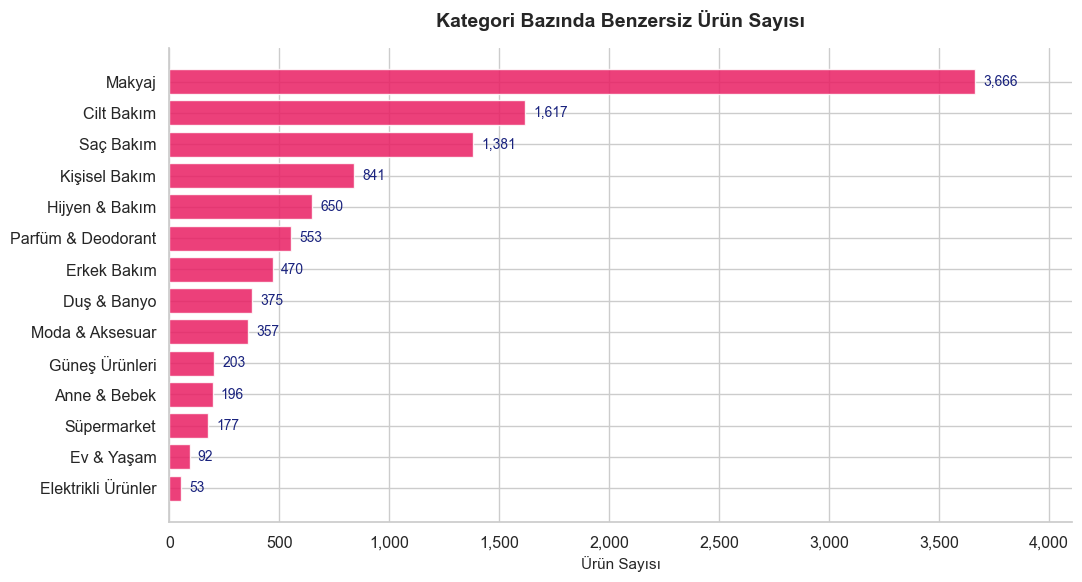


En büyük kategori: Makyaj (3,666 ürün)
En küçük kategori: Elektrikli Ürünler (53 ürün)
Ortalama kategori büyüklüğü: 759 ürün


In [29]:
# === KATEGORİ DAĞILIMI ===
# Her kategoride kaç benzersiz ürün var?

kategori_urun = df.groupby("kategori")["urun_id"].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(kategori_urun.index, kategori_urun.values, color=GRATIS_PEMBE, alpha=0.85)

# Her barın ucuna sayıyı yaz
for bar, val in zip(bars, kategori_urun.values):
    ax.text(val + max(kategori_urun.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10, color=GRATIS_LACIVERT)

ax.set_title("Kategori Bazında Benzersiz Ürün Sayısı", pad=15)
ax.set_xlabel("Ürün Sayısı")
ax.set_ylabel("")
ax.set_xlim(0, kategori_urun.max() * 1.12)

# Eksen değerlerini binlik formatla
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# Yorum için sayıları yazdır
print(f"\nEn büyük kategori: {kategori_urun.idxmax()} ({kategori_urun.max():,} ürün)")
print(f"En küçük kategori: {kategori_urun.idxmin()} ({kategori_urun.min():,} ürün)")
print(f"Ortalama kategori büyüklüğü: {kategori_urun.mean():.0f} ürün")

**Bulgu — Kategori Yoğunluğu:**

- **Makyaj** açık ara en kalabalık kategori (3,666 ürün, toplamın ~%34'ü) → Gratis'in ürün portföyünün ağırlık merkezi.
- İlk üç kategori (Makyaj + Cilt Bakım + Saç Bakım) toplam katalogun yaklaşık **%62'sini** oluşturuyor → güzellik/bakım odaklı bir perakendeci profili.
- **Elektrikli Ürünler (53)** ve **Ev & Yaşam (92)** gibi düşük temsilli kategorilerden çıkarılacak istatistikler dikkatle yorumlanmalıdır — örneklem sayısı az olduğunda ortalamalar volatil olur.

Bu dağılım, sonraki bölümlerde kategori bazlı kıyaslamaların *ağırlıksız değil ağırlıklı* yorumlanması gerektiğini gösterir.

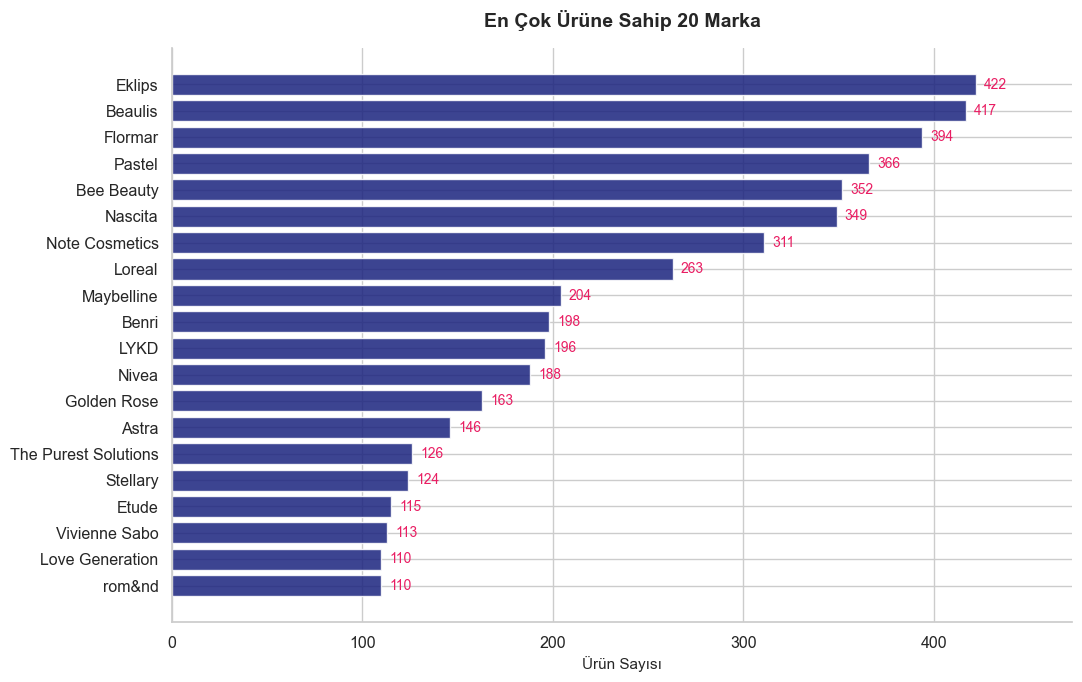


Toplam marka sayısı: 422
En büyük marka: Eklips (422 ürün)
Top 20 markanın toplam ürün payı: %43.9
Tek ürünlü marka sayısı: 48


In [30]:
# === MARKA DAĞILIMI (TOP 20) ===
# 422 marka var, hepsini göstermek anlamsız — en büyük 20'sini göster

marka_urun = df.groupby("marka")["urun_id"].nunique().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(marka_urun.index[::-1], marka_urun.values[::-1], color=GRATIS_LACIVERT, alpha=0.85)

# Sayıları barların ucuna yaz
for bar, val in zip(bars, marka_urun.values[::-1]):
    ax.text(val + max(marka_urun.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10, color=GRATIS_PEMBE)

ax.set_title("En Çok Ürüne Sahip 20 Marka", pad=15)
ax.set_xlabel("Ürün Sayısı")
ax.set_ylabel("")
ax.set_xlim(0, marka_urun.max() * 1.12)

plt.tight_layout()
plt.show()

# Marka dağılımı özeti
print(f"\nToplam marka sayısı: {df['marka'].nunique()}")
print(f"En büyük marka: {marka_urun.idxmax()} ({marka_urun.max()} ürün)")
print(f"Top 20 markanın toplam ürün payı: %{marka_urun.sum() / df['urun_id'].nunique() * 100:.1f}")
print(f"Tek ürünlü marka sayısı: {(df.groupby('marka')['urun_id'].nunique() == 1).sum()}")

In [31]:
# "The" markasıyla görünen ürünlerden örnek isimler
the_ornekler = df[df["marka"] == "The"]["isim"].drop_duplicates().head(20).tolist()
for isim in the_ornekler:
    print(f"  - {isim}")

In [32]:
# Şüphelenip doğrulamak istediğim çok kelimeli markalar
# Senin verinde bunların "ilk kelimesi" var mı bakalım
adaylar = ["Bee", "Love", "Vivienne", "Wet", "Some", "Hada", "Body", "Organic",
           "Planet", "Physicians", "Beauty", "Influence", "Eklips", "Beaulis",
           "Benri", "Hyp", "Miss", "Life", "VT", "Much", "360", "Ayouth",
           "Dina", "Milton", "farm", "Jeanne", "Mary", "Dr.", "Chupa",
           "Glossy", "Green", "Laction", "Note", "Golden", "Pastel",
           "Hada", "theBalm", "Lykd", "Gratis"]

for marka in adaylar:
    urun_sayisi = df[df["marka"] == marka]["urun_id"].nunique()
    if urun_sayisi > 0:
        ornek = df[df["marka"] == marka]["isim"].iloc[0]
        print(f"[{marka}] ({urun_sayisi} ürün) → örnek: {ornek[:80]}")

[Eklips] (422 ürün) → örnek: Eklips Seyahat Seti 2'li SA70931
[Beaulis] (417 ürün) → örnek: Beaulis Paint It Oje 999 Transparent
[Benri] (198 ürün) → örnek: Benri Lavanta Kağıt Sabun 20'li
[Mary] (5 ürün) → örnek: Mary & May Bakuchiol İçerikli 50SPF Stick Güneş Kremi 18 gr
[Dr.] (10 ürün) → örnek: Dr. Pawpaw Tinted Ultimate Red Balm 10 ml
[Chupa] (8 ürün) → örnek: Chupa Chups 3D Skull Çilek & Misket Limonu
[Glossy] (8 ürün) → örnek: Glossy Blossom Tırnak Süsleme Sticker Cuevly-966760
[Green] (25 ürün) → örnek: Green Therapy Krem Saç Boyası 1.0 Siyah
[Laction] (1 ürün) → örnek: Laction Paris Kirpik Güçlendirici Maskara
[Pastel] (366 ürün) → örnek: Pastel Matte Waterproof Long Lasting Eyeliner 320
[theBalm] (45 ürün) → örnek: theBalm Sexy Mama Transparan Pudra


In [33]:
# === MARKA TEMİZLEME ===
# Scraper "ilk kelime" stratejisiyle çekiyor, çok kelimeli markaları bozuyor
# Doğrulanmış mapping (Gratis resmi marka listesi + örnek ürünlerle teyit edildi)

marka_duzeltme = {
    "Bee": "Bee Beauty",
    "Love": "Love Generation",
    "Vivienne": "Vivienne Sabo",
    "Some": "Some By Mi",
    "Hada": "Hada Labo Tokyo",
    "Body": "Body Fantasies",
    "Organic": "Organic Shop",
    "Planet": "Planet Essence",
    "Physicians": "Physicians Formula",
    "Beauty": "Beauty Bomb",
    "Influence": "Influence Beauty",
    "Hyp": "Hyp Me",
    "Miss": "Miss Kay",
    "Life": "Life In",
    "VT": "VT Cosmetics",
    "Much": "Much More Than",
    "360": "360 Hair Professional",
    "Ayouth": "Ayouth Veda",
    "Dina": "Dina Cosmetics",
    "Milton": "Milton Lloyd Essentials",
    "farm": "farm Rx",
    "Jeanne": "Jeanne Arthes",
    "Golden": "Golden Rose",
    "Note": "Note Cosmetics",
    "The": "The Purest Solutions",   # doğrulandı: hepsi tek marka
    "Pastel": "Pastel",               # zaten doğru, dokunma
}

# Mapping'i uygula (mapping'de olmayan markalar olduğu gibi kalır)
df["marka"] = df["marka"].replace(marka_duzeltme)

# Sonuç doğrulama
yeni_marka_sayisi = df["marka"].nunique()
print(f"Düzeltme sonrası marka sayısı: {yeni_marka_sayisi}")
print(f"\n=== YENİ TOP 15 MARKA ===")
top15 = df.groupby("marka")["urun_id"].nunique().sort_values(ascending=False).head(15)
for marka, sayi in top15.items():
    print(f"  {marka:.<35} {sayi:>4} ürün")

Düzeltme sonrası marka sayısı: 422

=== YENİ TOP 15 MARKA ===
  Eklips.............................  422 ürün
  Beaulis............................  417 ürün
  Flormar............................  394 ürün
  Pastel.............................  366 ürün
  Bee Beauty.........................  352 ürün
  Nascita............................  349 ürün
  Note Cosmetics.....................  311 ürün
  Loreal.............................  263 ürün
  Maybelline.........................  204 ürün
  Benri..............................  198 ürün
  LYKD...............................  196 ürün
  Nivea..............................  188 ürün
  Golden Rose........................  163 ürün
  Astra..............................  146 ürün
  The Purest Solutions...............  126 ürün


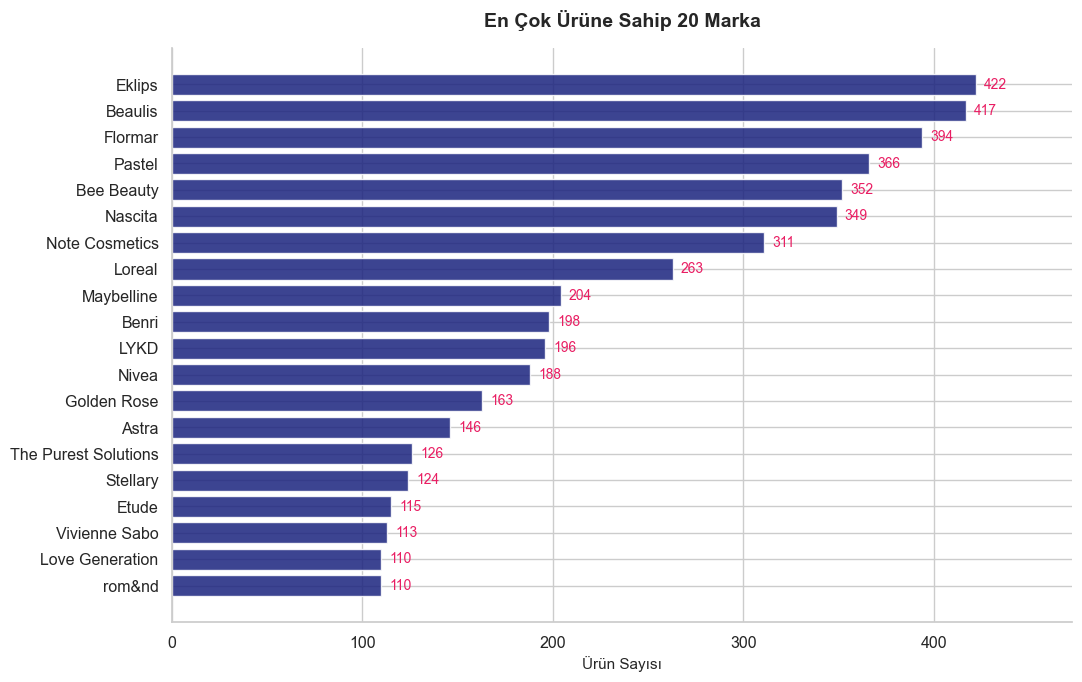


Top 20 markanın toplam ürün payı: %43.9
Toplam marka sayısı: 422


In [34]:
# === YENİ TOP 20 MARKA GRAFİĞİ ===
marka_urun = df.groupby("marka")["urun_id"].nunique().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(marka_urun.index[::-1], marka_urun.values[::-1], color=GRATIS_LACIVERT, alpha=0.85)

for bar, val in zip(bars, marka_urun.values[::-1]):
    ax.text(val + max(marka_urun.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10, color=GRATIS_PEMBE)

ax.set_title("En Çok Ürüne Sahip 20 Marka", pad=15)
ax.set_xlabel("Ürün Sayısı")
ax.set_xlim(0, marka_urun.max() * 1.12)

plt.tight_layout()
plt.show()

# Pareto: Top 20 markanın toplam paydaki yeri
top20_pay = marka_urun.sum() / df["urun_id"].nunique() * 100
print(f"\nTop 20 markanın toplam ürün payı: %{top20_pay:.1f}")
print(f"Toplam marka sayısı: {df['marka'].nunique()}")

---

## 2) Fiyat Yapısı

Veri setinin önemli bir özelliği: ortalama (345 TL) medyandan (200 TL) belirgin yüksek. Bu, dağılımın **sağa çarpık** olduğunu söylüyor — yani az sayıda pahalı ürün ortalamayı yukarı çekiyor. Bu bölümde fiyatların gerçek yapısını anlayacağız.

Sorular:
- Fiyatlar nasıl dağılıyor?
- Aşırı uç değer (outlier) var mı, nereden geliyor?
- Hangi fiyat segmentlerinde yoğunlaşma var?

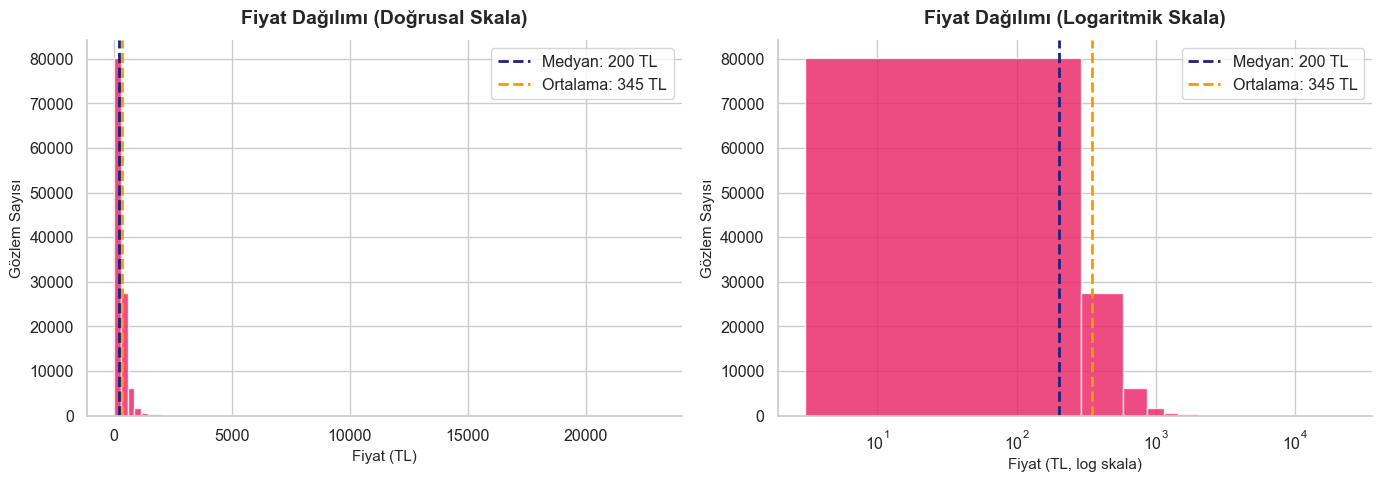


=== FİYAT İSTATİSTİKLERİ ===
count    118812.00
mean        345.24
std         804.60
min           3.00
25%         115.50
50%         200.00
75%         341.00
max       22929.00
Name: fiyat, dtype: float64

=== FİYAT YÜZDELİKLERİ ===
  %10 →     69.00 TL
  %25 →    115.50 TL
  %50 →    200.00 TL
  %75 →    341.00 TL
  %90 →    550.00 TL
  %95 →    814.50 TL
  %99 →   3396.00 TL

Çarpıklık (skewness): 10.90  (0=simetrik, >0=sağa çarpık)
Sağa çarpık dağılım → birkaç pahalı ürün ortalamayı yukarı çekiyor


In [35]:
# === FİYAT DAĞILIMI: NORMAL + LOG SKALA ===
# Sağa çarpık dağılımlarda log dönüşümü gerçek yapıyı ortaya çıkarır

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: normal skala
axes[0].hist(df["fiyat"], bins=80, color=GRATIS_PEMBE, alpha=0.8, edgecolor="white")
axes[0].set_title("Fiyat Dağılımı (Doğrusal Skala)", pad=12)
axes[0].set_xlabel("Fiyat (TL)")
axes[0].set_ylabel("Gözlem Sayısı")
axes[0].axvline(df["fiyat"].median(), color=GRATIS_LACIVERT, linestyle="--", linewidth=2,
                label=f"Medyan: {df['fiyat'].median():.0f} TL")
axes[0].axvline(df["fiyat"].mean(), color=ACCENT, linestyle="--", linewidth=2,
                label=f"Ortalama: {df['fiyat'].mean():.0f} TL")
axes[0].legend()

# Sağ: log skala (sağa çarpık dağılımları normalize eder)
axes[1].hist(df["fiyat"], bins=80, color=GRATIS_PEMBE, alpha=0.8, edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Fiyat Dağılımı (Logaritmik Skala)", pad=12)
axes[1].set_xlabel("Fiyat (TL, log skala)")
axes[1].set_ylabel("Gözlem Sayısı")
axes[1].axvline(df["fiyat"].median(), color=GRATIS_LACIVERT, linestyle="--", linewidth=2,
                label=f"Medyan: {df['fiyat'].median():.0f} TL")
axes[1].axvline(df["fiyat"].mean(), color=ACCENT, linestyle="--", linewidth=2,
                label=f"Ortalama: {df['fiyat'].mean():.0f} TL")
axes[1].legend()

plt.tight_layout()
plt.show()

# Detaylı istatistikler
print("\n=== FİYAT İSTATİSTİKLERİ ===")
print(df["fiyat"].describe().round(2))

print("\n=== FİYAT YÜZDELİKLERİ ===")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  %{p:>2} → {df['fiyat'].quantile(p/100):>9.2f} TL")

# Çarpıklık ve basıklık (dağılım şekli ölçütleri)
from scipy import stats
skew = stats.skew(df["fiyat"])
print(f"\nÇarpıklık (skewness): {skew:.2f}  (0=simetrik, >0=sağa çarpık)")
print(f"Sağa çarpık dağılım → birkaç pahalı ürün ortalamayı yukarı çekiyor")

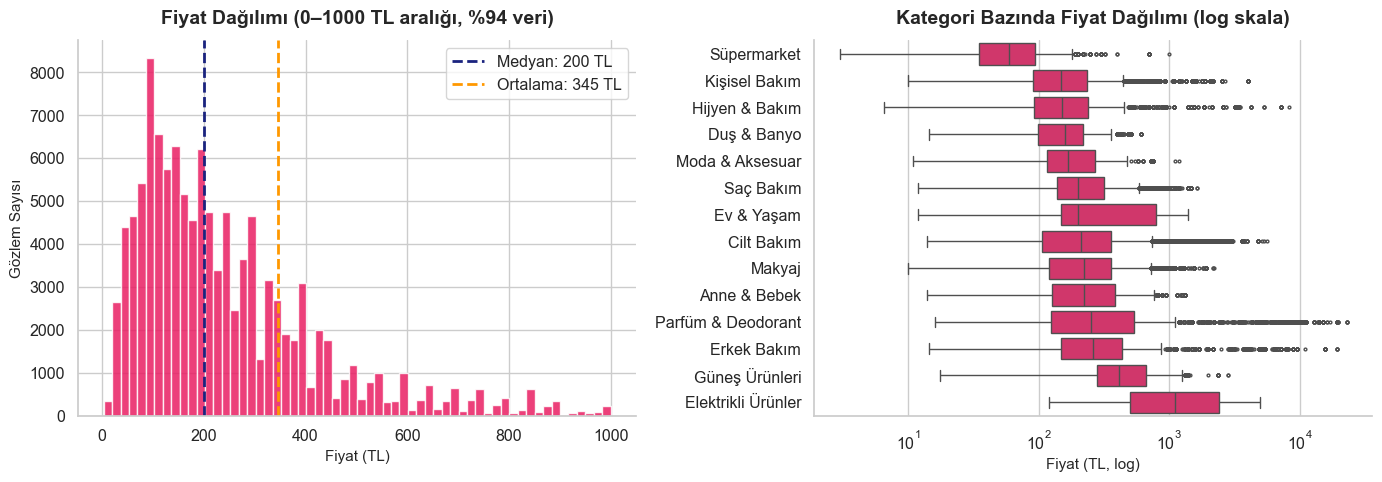


=== KATEGORİ BAZINDA FİYAT İSTATİSTİKLERİ ===
                    Medyan  Ortalama      Max
kategori                                     
Elektrikli Ürünler  1099.0   1631.21   4999.0
Güneş Ürünleri       415.0    503.42   2800.0
Erkek Bakım          259.0    669.64  19299.0
Parfüm & Deodorant   250.0   1265.55  22929.0
Anne & Bebek         224.0    304.52   1319.0
Makyaj               222.5    274.70   2198.0
Cilt Bakım           209.5    335.29   5620.0
Ev & Yaşam           199.5    441.40   1399.0
Saç Bakım            199.0    242.69   1620.0
Moda & Aksesuar      169.0    199.63   1199.0
Duş & Banyo          159.0    166.69    610.0
Hijyen & Bakım       150.5    247.96   8210.0
Kişisel Bakım        148.0    211.77   3991.0
Süpermarket           59.0     76.76    999.5


In [36]:
# Sol histogramı okunur hale getirmek için %99 yüzdeliği üstünü kes
# Boxplot ile birlikte gösterelim — outlier'ları net görmek için

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: 0-1000 TL aralığına zoom (gerçek hikaye burada)
fiyat_zoom = df[df["fiyat"] <= 1000]["fiyat"]
axes[0].hist(fiyat_zoom, bins=60, color=GRATIS_PEMBE, alpha=0.85, edgecolor="white")
axes[0].set_title("Fiyat Dağılımı (0–1000 TL aralığı, %94 veri)", pad=12)
axes[0].set_xlabel("Fiyat (TL)")
axes[0].set_ylabel("Gözlem Sayısı")
axes[0].axvline(df["fiyat"].median(), color=GRATIS_LACIVERT, linestyle="--", linewidth=2,
                label=f"Medyan: {df['fiyat'].median():.0f} TL")
axes[0].axvline(df["fiyat"].mean(), color=ACCENT, linestyle="--", linewidth=2,
                label=f"Ortalama: {df['fiyat'].mean():.0f} TL")
axes[0].legend()

# Sağ: kategori bazında boxplot (log skala) — uç değerlerin nereden geldiğini gösterir
kat_sira = df.groupby("kategori")["fiyat"].median().sort_values().index
sns.boxplot(
    data=df,
    x="fiyat",
    y="kategori",
    order=kat_sira,
    color=GRATIS_PEMBE,
    fliersize=2,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Kategori Bazında Fiyat Dağılımı (log skala)", pad=12)
axes[1].set_xlabel("Fiyat (TL, log)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Hangi kategori en pahalı?
print("\n=== KATEGORİ BAZINDA FİYAT İSTATİSTİKLERİ ===")
kategori_fiyat = df.groupby("kategori")["fiyat"].agg(["median", "mean", "max"]).round(2)
kategori_fiyat.columns = ["Medyan", "Ortalama", "Max"]
print(kategori_fiyat.sort_values("Medyan", ascending=False))

**Bulgu — Fiyat Yapısı:**

- **Bimodal (iki tepeli) dağılım:** Fiyatlar iki belirgin yığında topluyor — ~100 TL civarında küçük tüketim malzemeleri (sünger, küçük makyaj, sabun) ve ~200 TL civarında ana kozmetik segmenti. Bu, Gratis'in iki farklı tüketici davranışını hedeflediğini gösteriyor: hızlı tüketim ile düşünülmüş satın alma.

- **Aşırı sağa çarpıklık (skewness ≈ 11):** Çok pahalı birkaç ürün (özellikle parfüm setleri ve elektrikli aletler) ortalamayı medyanın **1.7 katına** çekiyor. Bu yüzden tüm analizlerde **medyan ortalamadan daha temsil edici**.

- **Kategori bazında belirgin segmentasyon:**
  - **Premium segment:** Elektrikli Ürünler (medyan 1099 TL), Güneş Ürünleri (415 TL)
  - **Orta segment:** Parfüm, Erkek Bakım, Makyaj, Cilt Bakım (~220–260 TL)
  - **Ekonomik segment:** Süpermarket (59 TL), Kişisel Bakım (148 TL), Duş & Banyo (159 TL)

- **Outlier analizi:** Parfüm & Deodorant kategorisinde max fiyat **22,929 TL**, Erkek Bakım'da **19,299 TL** — bunlar muhtemelen lüks parfüm setleri veya elektrikli tıraş makinesi paketleri. Anomali tespiti bölümünde bu uç değerleri detaylı inceleyeceğiz.

**Modelleme implikasyonu:** Sağa çarpık dağılım, ML modellerinde **log dönüşümü** uygulamamız gerektiğini söylüyor — özellikle fiyat tabanlı özelliklerde.

---

## 3) İndirim Manzarası

İlk genel manzara bize **gözlemlerin %93.3'ünün indirimde** olduğunu söyledi. Bu rakam başlı başına ilginç — Türkiye perakendesinde "her zaman indirimli görme" deseni güçlü bir gerçeklik. Bu bölümde:

- İndirim oranlarının dağılımı
- Kategori bazında indirim agresifliği
- "Sürekli indirim" pattern'inin varlığı
- Şüpheli indirim hikâyelerine ilk bakış

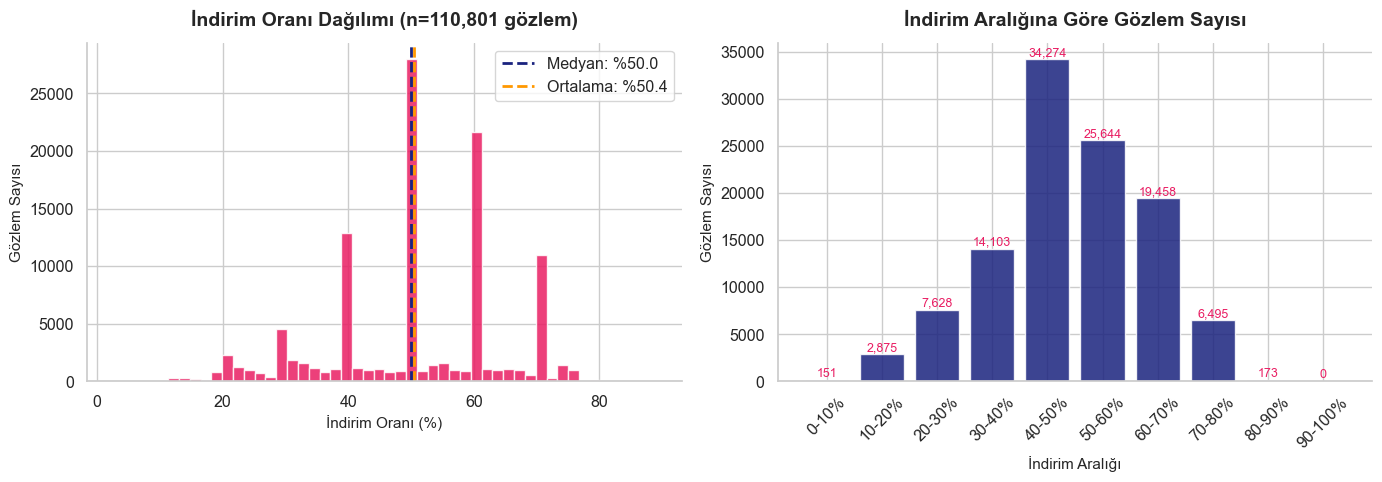


=== İNDİRİM İSTATİSTİKLERİ (sadece indirimli gözlemler) ===
count    110801.00
mean         50.41
std          13.92
min           2.70
25%          40.10
50%          50.00
75%          60.00
max          88.80
Name: indirim_yuzde, dtype: float64

=== KRİTİK PATTERN ===
İndirimde olan gözlem: 110,801 (%93.3)
İndirimsiz gözlem: 8,011 (%6.7)
En sık görülen indirim aralığı: 40-50%


In [37]:
# === İNDİRİM ORANI DAĞILIMI ===
# Sadece gerçekten indirimde olan gözlemleri al (indirim_yuzde > 0)
indirimli = df[df["indirimde_mi"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: İndirim oranı histogramı
axes[0].hist(indirimli["indirim_yuzde"], bins=50, color=GRATIS_PEMBE, alpha=0.85, edgecolor="white")
axes[0].set_title(f"İndirim Oranı Dağılımı (n={len(indirimli):,} gözlem)", pad=12)
axes[0].set_xlabel("İndirim Oranı (%)")
axes[0].set_ylabel("Gözlem Sayısı")
axes[0].axvline(indirimli["indirim_yuzde"].median(), color=GRATIS_LACIVERT,
                linestyle="--", linewidth=2,
                label=f"Medyan: %{indirimli['indirim_yuzde'].median():.1f}")
axes[0].axvline(indirimli["indirim_yuzde"].mean(), color=ACCENT,
                linestyle="--", linewidth=2,
                label=f"Ortalama: %{indirimli['indirim_yuzde'].mean():.1f}")
axes[0].legend()

# Sağ: İndirim oranı binleri (segmentler)
binler = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
indirimli["indirim_segment"] = pd.cut(indirimli["indirim_yuzde"], bins=binler,
                                       labels=["0-10%", "10-20%", "20-30%", "30-40%",
                                               "40-50%", "50-60%", "60-70%", "70-80%",
                                               "80-90%", "90-100%"])
segment_sayilari = indirimli["indirim_segment"].value_counts().sort_index()

bars = axes[1].bar(range(len(segment_sayilari)), segment_sayilari.values,
                    color=GRATIS_LACIVERT, alpha=0.85, edgecolor="white")
axes[1].set_xticks(range(len(segment_sayilari)))
axes[1].set_xticklabels(segment_sayilari.index, rotation=45)
axes[1].set_title("İndirim Aralığına Göre Gözlem Sayısı", pad=12)
axes[1].set_xlabel("İndirim Aralığı")
axes[1].set_ylabel("Gözlem Sayısı")

# Sayıları barların üstüne yaz
for bar, val in zip(bars, segment_sayilari.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(segment_sayilari)*0.01,
                 f"{val:,}", ha="center", fontsize=9, color=GRATIS_PEMBE)

plt.tight_layout()
plt.show()

# Özet
print("\n=== İNDİRİM İSTATİSTİKLERİ (sadece indirimli gözlemler) ===")
print(indirimli["indirim_yuzde"].describe().round(2))

print(f"\n=== KRİTİK PATTERN ===")
print(f"İndirimde olan gözlem: {len(indirimli):,} (%{len(indirimli)/len(df)*100:.1f})")
print(f"İndirimsiz gözlem: {(~df['indirimde_mi']).sum():,} (%{(~df['indirimde_mi']).mean()*100:.1f})")
print(f"En sık görülen indirim aralığı: {segment_sayilari.idxmax()}")

**Bulgu — İndirim Stratejisinin Kalbi: "Sihirli %50":**

İndirim oranı histogramı **rastgele değil, son derece yapılandırılmış bir desen** gösteriyor:

- **%50'de devasa bir tepe (28K gözlem):** Tek başına en sık görülen indirim oranı. Bu, tesadüf değil — psikolojik fiyatlama stratejisinin somut kanıtı. "%50 indirim" tüketici algısında en güçlü tetikleyicidir.
- **Yuvarlak yüzdelerde tepe kümeleri:** %20, %30, %40, %50, %60, %70'te sivri tepeler; aradaki ondalık değerlerde (örn. %37, %53) neredeyse hiç gözlem yok. Bu, **fiyatlama sisteminin yuvarlak değerleri zorladığını** gösteriyor.
- **40-60% bandında yoğunlaşma:** Toplam indirimli ürünlerin **%63'ü** bu aralıkta — Gratis'in "iyi indirim" olarak konumlandırdığı tatlı nokta.
- **%80+ indirim neredeyse yok (sadece 173 gözlem):** Çok agresif indirimler nadir — muhtemelen stok eritme veya sezon sonu kalıntıları.

**Stratejik yorum:** Bu desen, indirim oranlarının **algoritmik fiyatlama yerine pazarlama odaklı kararlarla** belirlendiğini düşündürüyor. Şu soruyu doğuruyor: *Eğer indirim oranı her zaman aynı "yuvarlak rakam"a sabitleniyorsa, bu indirim gerçek mi yoksa fiyat zaten %50 yüksek belirlenip sonra "indirim" olarak mı sunuluyor?* Sahte indirim hipotezimizin temellerinden biri budur.

=== KATEGORİ BAZINDA İNDİRİM AGRESİFLİĞİ ===

                    toplam_gozlem  indirimli_oran  ortalama_indirim  medyan_indirim
kategori                                                                           
Elektrikli Ürünler            601           100.0             57.99            60.0
Makyaj                      42145            90.0             56.47            55.7
Güneş Ürünleri               2189            98.0             53.78            50.0
Cilt Bakım                  18005            98.0             53.15            50.1
Saç Bakım                   14879            97.0             49.26            50.0
Moda & Aksesuar              3494            91.0             48.63            45.2
Hijyen & Bakım               7029            90.0             46.37            45.1
Ev & Yaşam                   1076            91.0             45.69            40.4
Parfüm & Deodorant           6104            93.0             45.42            50.0
Duş & Banyo                  4

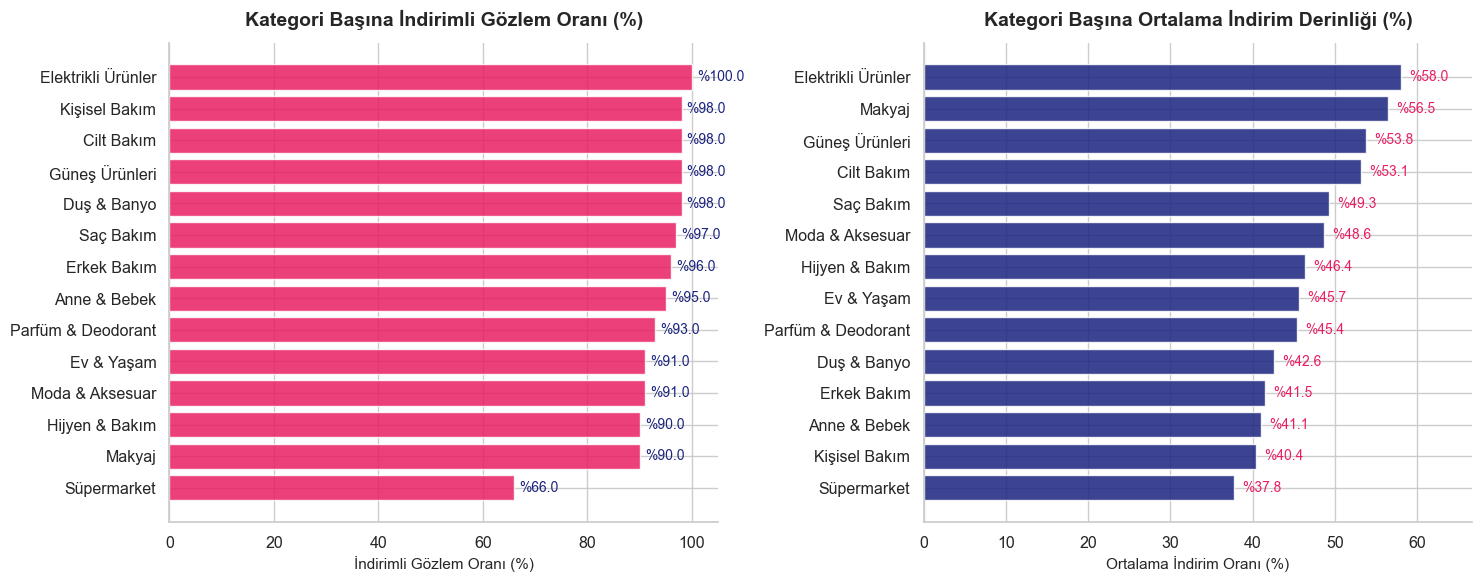

In [38]:
# === KATEGORİ × İNDİRİM AGRESİFLİĞİ ===
# Her kategoride ortalama indirim ve indirimli ürün oranı

kategori_indirim = df.groupby("kategori").agg(
    toplam_gozlem=("indirim_yuzde", "size"),
    indirimli_oran=("indirimde_mi", "mean"),
    ortalama_indirim=("indirim_yuzde", lambda x: x[x > 0].mean()),
    medyan_indirim=("indirim_yuzde", lambda x: x[x > 0].median()),
).round(2).sort_values("ortalama_indirim", ascending=False)

kategori_indirim["indirimli_oran"] = (kategori_indirim["indirimli_oran"] * 100).round(1)

print("=== KATEGORİ BAZINDA İNDİRİM AGRESİFLİĞİ ===\n")
print(kategori_indirim.to_string())

# Görselleştirme: iki yan yana bar
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: İndirimli ürün oranı (%)
data1 = kategori_indirim["indirimli_oran"].sort_values()
axes[0].barh(data1.index, data1.values, color=GRATIS_PEMBE, alpha=0.85)
axes[0].set_title("Kategori Başına İndirimli Gözlem Oranı (%)", pad=12)
axes[0].set_xlabel("İndirimli Gözlem Oranı (%)")
axes[0].set_xlim(0, 105)
for i, val in enumerate(data1.values):
    axes[0].text(val + 1, i, f"%{val:.1f}", va="center", fontsize=10, color=GRATIS_LACIVERT)

# Sağ: Ortalama indirim derinliği
data2 = kategori_indirim["ortalama_indirim"].sort_values()
axes[1].barh(data2.index, data2.values, color=GRATIS_LACIVERT, alpha=0.85)
axes[1].set_title("Kategori Başına Ortalama İndirim Derinliği (%)", pad=12)
axes[1].set_xlabel("Ortalama İndirim Oranı (%)")
axes[1].set_xlim(0, max(data2.values) * 1.15)
for i, val in enumerate(data2.values):
    axes[1].text(val + 1, i, f"%{val:.1f}", va="center", fontsize=10, color=GRATIS_PEMBE)

plt.tight_layout()
plt.show()

**Bulgu — Kategorilerin İndirim Karakteri:**

| Kategori Profili | Örnek Kategoriler | Yorum |
|---|---|---|
| **Şüpheli sürekli indirim** | Elektrikli Ürünler (%100 indirim oranı, %58 derinlik) | Hiçbir gözlem normal fiyattan değil → ya etiket fiyatı şişirilmiş ya da promosyonel pazarlama stratejisi |
| **Hacim + derinlik kombinasyonu** | Makyaj (42K gözlem, %56.5 derinlik) | Yüksek hacimli kategoride agresif fiyatlama — impulse buying'i besliyor |
| **Premium algı + sürekli indirim** | Güneş Ürünleri, Cilt Bakım (%98 oran, %53 derinlik) | Tüketici "iyi indirim" hissi yaşıyor ama fiyat kalıcı olarak indirimli |
| **Gerçekten farklı kategori** | Süpermarket (%66 oran, %38 derinlik) | Gıda/temizlik gibi temel tüketim — düşük marjlar nedeniyle agresif indirim mümkün değil |

**Kritik Sonuç:** 14 kategoriden **12'sinin indirimli ürün oranı %90'ın üzerinde**. Bu, "indirim" kavramının Gratis kataloğunda **normalleşmiş**, neredeyse varsayılan durum haline geldiğini gösteriyor. Bu da bizi **"gerçek vs algoritmik indirim"** sorusuna götürüyor — anomali tespiti bölümünde derinleştireceğimiz konu.

**Modelleme implikasyonu:** "İndirimde mi?" binary değişkeni neredeyse hiç ayrım yapmıyor (%93 hep True). Bunun yerine **indirim derinliği** (ne kadar indirim) ve **indirim sıklığı** (zaman içinde ne kadar süre indirimde) çok daha ayırt edici özellikler olacak.

---

## 4) Zaman Dinamiği

15 farklı gözlem günü elimde — şimdi şuna bakacağız: **Fiyat ve indirim oranları zaman içinde nasıl hareket etti?** Eğer fiyatlar sabit kalıyor ve indirim oranları sabit kalıyorsa → "sürekli indirim" hipotezi güçleniyor. Eğer dalgalanma varsa → gerçek kampanya dinamiği var demektir.

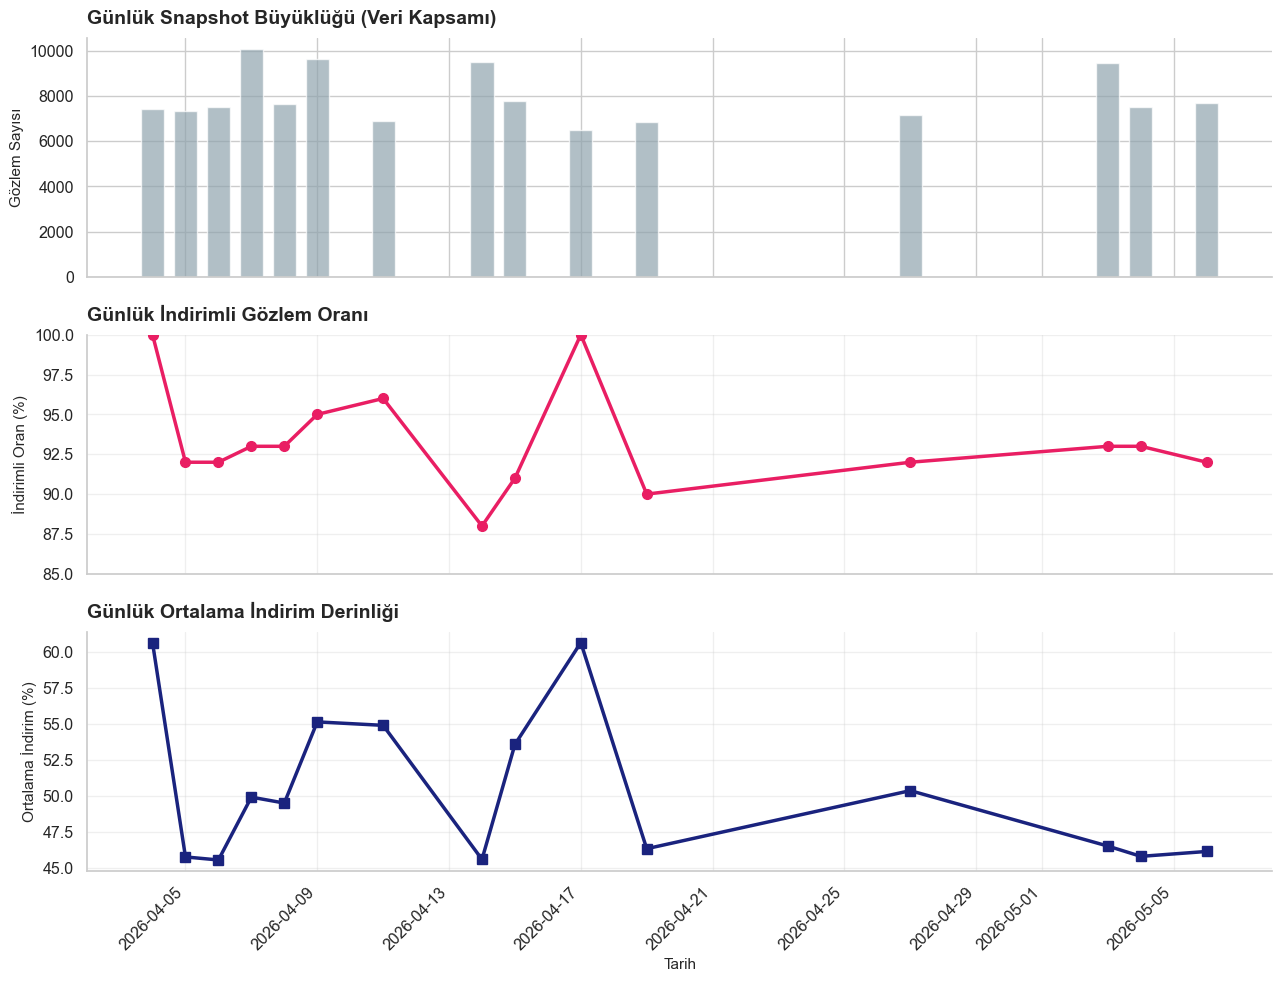


=== GÜNLÜK ÖZET TABLOSU ===
              gozlem_sayisi  indirimli_oran  ortalama_indirim  medyan_fiyat
snapshot_gun                                                               
2026-04-04             7410           100.0             60.62        159.50
2026-04-05             7320            92.0             45.78        218.25
2026-04-06             7495            92.0             45.57        215.00
2026-04-07            10067            93.0             49.92        199.50
2026-04-08             7649            93.0             49.51        199.50
2026-04-09             9630            95.0             55.13        179.00
2026-04-11             6874            96.0             54.89        179.00
2026-04-14             9476            88.0             45.61        219.50
2026-04-15             7771            91.0             53.57        199.00
2026-04-17             6475           100.0             60.62        171.50
2026-04-19             6826            90.0             46.

In [39]:
# === GÜNLÜK ORTALAMA İNDİRİM ORANI ===
gunluk = df.groupby("snapshot_gun").agg(
    gozlem_sayisi=("urun_id", "count"),
    indirimli_oran=("indirimde_mi", "mean"),
    ortalama_indirim=("indirim_yuzde", lambda x: x[x > 0].mean()),
    medyan_fiyat=("fiyat", "median"),
).round(2)
gunluk["indirimli_oran"] = (gunluk["indirimli_oran"] * 100).round(1)

# 3'lü panel grafik
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# 1. Günlük gözlem sayısı (snapshot büyüklüğü)
axes[0].bar(gunluk.index, gunluk["gozlem_sayisi"], color=GRATIS_GRI, alpha=0.7,
            width=0.7, edgecolor="white")
axes[0].set_ylabel("Gözlem Sayısı")
axes[0].set_title("Günlük Snapshot Büyüklüğü (Veri Kapsamı)", pad=10, loc="left")

# 2. İndirimli gözlem oranı (%)
axes[1].plot(gunluk.index, gunluk["indirimli_oran"], color=GRATIS_PEMBE,
             marker="o", linewidth=2.5, markersize=7)
axes[1].set_ylabel("İndirimli Oran (%)")
axes[1].set_title("Günlük İndirimli Gözlem Oranı", pad=10, loc="left")
axes[1].set_ylim(85, 100)
axes[1].grid(True, alpha=0.3)

# 3. Ortalama indirim derinliği (%)
axes[2].plot(gunluk.index, gunluk["ortalama_indirim"], color=GRATIS_LACIVERT,
             marker="s", linewidth=2.5, markersize=7)
axes[2].set_ylabel("Ortalama İndirim (%)")
axes[2].set_xlabel("Tarih")
axes[2].set_title("Günlük Ortalama İndirim Derinliği", pad=10, loc="left")
axes[2].grid(True, alpha=0.3)

# Tarih etiketlerini eğ
for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

print("\n=== GÜNLÜK ÖZET TABLOSU ===")
print(gunluk)

**Bulgu — Zaman Dinamiği: Sabitlik İçinde Hareket:**

İlk bakışta indirim oranı %90 bandında stabil görünüyor ama panel görseli **daha derin bir hikâye** anlatıyor:

**1) Veri toplama profili:**
- 15 günde toplam 118K gözlem, ortalama günlük 7-10K
- **21-26 Nisan arasında veri yok** — bu dönem 23-25 Nisan "DEV FIRSAT" kampanyası ile örtüşüyor, kaçırılan kampanya bilgisi olarak raporda not edildi
- Snapshot sıklığı düzenli olmasa da yeterli temsil sağlıyor

**2) İki belirgin "kampanya zirvesi":**
- **4 Nisan 2026 (~%60 derinlik, %100 indirim oranı):** Gratis'in resmi olarak duyurduğu **"1-10 Nisan Makyaj + Saç Bakım Bahar Kampanyası"** ile örtüşüyor. Veri bunu doğruluyor — kampanya başlangıç günü en agresif fiyatlama.
- **17 Nisan 2026 (~%60 derinlik):** İkinci zirve. Resmi kampanya duyurusunda doğrudan tarih bulunamadı; "bahar fırsatları" kapsamında ikinci dalga olabilir.

**3) Kampanya bittiğinde fiyatlar yarı yarıya geri çekiliyor:**
- 5-6 Nisan: derinlik **%60 → %46**'ya düşüyor
- 20 Nisan sonrası: %46 bandında stabilleşiyor

**Stratejik Yorum:**

Kalıcı indirim hipotezimiz **yarı doğru** çıktı: Gerçekten her zaman bir indirim var (%88-100 arası), AMA **derinlik dinamik**. Bu, Gratis'in iki katmanlı bir strateji uyguladığını gösteriyor:
- **Baz katman (her zaman):** ~%46 ortalama indirim — "indirimli ürünler"
- **Kampanya katmanları (dönemli):** %60+ derinliğe sıçramalar — gerçek pazarlama dalgaları

**Tüketici çıkarımı:** Belirli bir ürünü düşünüyorsan, kampanya zirvelerinde almak gerçekten avantajlı (~%14 daha fazla indirim). Kampanyaları takip eden tüketici fark yaratıyor. Bu, "fırsat skorlama" modelimizin temel motivasyonu.

**Modelleme implikasyonu:** Zaman serisi tahminine girmiyoruz (kapsam dışı) ama bu pattern bize sınıflandırma modelinde **"son 7 günde derinlik artışı"** gibi özelliklerin değerli olacağını gösteriyor.

---

## 5) Popülerlik ve İndirim İlişkisi

Yorum sayısı ve beğeni ürün popülerliğinin proxy göstergeleri. Şu hipotezi test edelim:

> **Popüler ürünler daha az indirime giriyor mu, yoksa popülerlik indirimle mi tetikleniyor?**

İki olası senaryo var:
- **Premium konumlanma:** Popüler ürünler stabil fiyatlı, az indirim — çünkü zaten talep var
- **İndirim odaklı popülerlik:** İndirim yapan ürünler yorum/beğeni topluyor, popülerlik indirimle besleniyor

Veri hangisini söyleyecek?

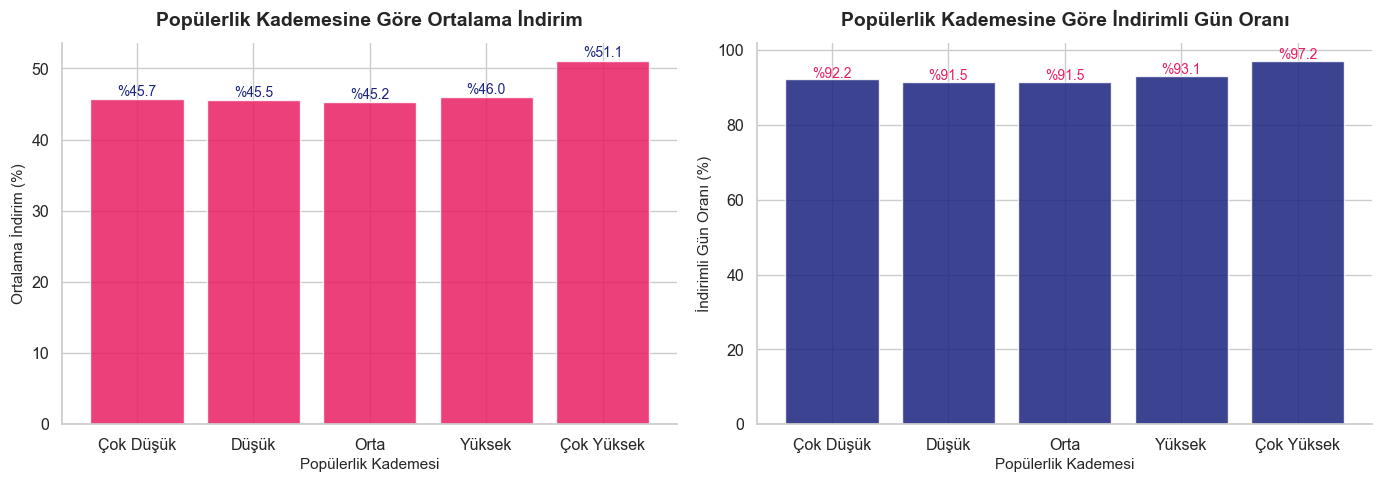


=== KORELASYON ANALİZİ ===
Popülerlik vs Ortalama İndirim:
  Pearson: 0.139
  Spearman: 0.114

Popülerlik vs İndirimli Gün Oranı:
  Pearson: 0.084
  Spearman: 0.054

[Not] Bu ürün-bazlı özet tablosu modelleme aşamasında temel olacak.
Toplam ürün: 10,628


In [40]:
# === POPÜLERLİK vs İNDİRİM ANALİZİ ===
# Her ürünün TEK SATIRA indirgenmiş özelliklerini hesapla
# (zaman serisinden ürün bazlı agregasyona geçiş)

urun_ozet = df.groupby("urun_id").agg(
    isim=("isim", "first"),
    kategori=("kategori", "first"),
    marka=("marka", "first"),
    ortalama_fiyat=("fiyat", "mean"),
    ortalama_indirim=("indirim_yuzde", "mean"),
    indirimli_gun_orani=("indirimde_mi", "mean"),
    yorum_sayisi=("yorum_sayisi", "max"),     # zamanla artar, max'ı al
    begeni_sayi=("begeni_sayi", "max"),
    gozlem_sayisi=("snapshot_gun", "nunique"),
).reset_index()

# Popülerlik skoru: yorum + beğeni'nin log birleşimi (büyüklük farkı için log)
urun_ozet["populerlik"] = np.log1p(urun_ozet["yorum_sayisi"].fillna(0)) + \
                          np.log1p(urun_ozet["begeni_sayi"].fillna(0))

# Popülerlik kademelerine ayır
urun_ozet["pop_kademe"] = pd.qcut(
    urun_ozet["populerlik"],
    q=5,
    labels=["Çok Düşük", "Düşük", "Orta", "Yüksek", "Çok Yüksek"],
    duplicates="drop"
)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Popülerlik kademesi - ortalama indirim
kademe_indirim = urun_ozet.groupby("pop_kademe", observed=True)["ortalama_indirim"].mean()
bars1 = axes[0].bar(range(len(kademe_indirim)), kademe_indirim.values,
                     color=GRATIS_PEMBE, alpha=0.85, edgecolor="white")
axes[0].set_xticks(range(len(kademe_indirim)))
axes[0].set_xticklabels(kademe_indirim.index)
axes[0].set_title("Popülerlik Kademesine Göre Ortalama İndirim", pad=12)
axes[0].set_xlabel("Popülerlik Kademesi")
axes[0].set_ylabel("Ortalama İndirim (%)")
for bar, val in zip(bars1, kademe_indirim.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"%{val:.1f}", ha="center", fontsize=10, color=GRATIS_LACIVERT)

# Sağ: Popülerlik kademesi - indirimli gün oranı
kademe_oran = urun_ozet.groupby("pop_kademe", observed=True)["indirimli_gun_orani"].mean()
bars2 = axes[1].bar(range(len(kademe_oran)), kademe_oran.values * 100,
                     color=GRATIS_LACIVERT, alpha=0.85, edgecolor="white")
axes[1].set_xticks(range(len(kademe_oran)))
axes[1].set_xticklabels(kademe_oran.index)
axes[1].set_title("Popülerlik Kademesine Göre İndirimli Gün Oranı", pad=12)
axes[1].set_xlabel("Popülerlik Kademesi")
axes[1].set_ylabel("İndirimli Gün Oranı (%)")
for bar, val in zip(bars2, kademe_oran.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"%{val:.1f}", ha="center", fontsize=10, color=GRATIS_PEMBE)

plt.tight_layout()
plt.show()

# Korelasyon: popülerlik ile indirim arasında istatistiksel ilişki var mı?
print("\n=== KORELASYON ANALİZİ ===")
print(f"Popülerlik vs Ortalama İndirim:")
print(f"  Pearson: {urun_ozet['populerlik'].corr(urun_ozet['ortalama_indirim']):.3f}")
print(f"  Spearman: {urun_ozet['populerlik'].corr(urun_ozet['ortalama_indirim'], method='spearman'):.3f}")
print(f"\nPopülerlik vs İndirimli Gün Oranı:")
print(f"  Pearson: {urun_ozet['populerlik'].corr(urun_ozet['indirimli_gun_orani']):.3f}")
print(f"  Spearman: {urun_ozet['populerlik'].corr(urun_ozet['indirimli_gun_orani'], method='spearman'):.3f}")

print(f"\n[Not] Bu ürün-bazlı özet tablosu modelleme aşamasında temel olacak.")
print(f"Toplam ürün: {len(urun_ozet):,}")